# KM Momentum — 6M — Winner Drift

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('km_momentum', '6M', 'winner_drift')

## 1. Signal and portfolio rule

Quality/liquidity universe → Close ≥ 1.03 × EMA(100) and bullish Supertrend(10,3) → raw-momentum ranking → highest N. There is no secondary proximity or risk ranking. A daily close below EMA(100), or a bearish Supertrend, triggers a sale at the next actual observed open. The proceeds earn the cash-sleeve return until the next scheduled rebalance.

### Technical definition

EMA(100) begins at the mean of the first 100 observed closes and thereafter uses α=2/101. ATR(10) begins at the mean of the first ten true ranges having a prior close, then uses Wilder's α=1/10 smoothing. Supertrend bands are HL2 ± 3×ATR; the prior bands govern direction changes and the active band cannot retreat while direction is unchanged. Direction starts bullish at the first valid ATR bar. Missing observations do not create synthetic indicator bars.

These initialization rules make the calculation reproducible. They do not claim exact equality with an unidentified historical charting-package version. All indicators use split/bonus-adjusted OHLC. The 3% buffer applies only to entry; the EMA exit has no 3% buffer.

Continuing holdings retain their naturally drifted weights, capped at 2/N at scheduled rebalances. Exits and entrants are paired in stable symbol order; an entrant receives min(exit weight, 1/N). Excess exit weight and cap trims are spread equally among continuing holdings with room below the cap. Unmatched entrants share existing cash up to 1/N each. Residual cash is retained. The cap is a scheduled target constraint, not a daily trim rule.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Formation price return,MDTV (INR)
NSE:YASHO-EQ,216.2%,"37,220,195.50"
NSE:CUPID-EQ,187.6%,"2,261,224,535.95"
NSE:DIACABS-EQ,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,145.8%,"129,439,974.50"
NSE:KSHINTL-EQ,142.6%,"194,129,104.07"
NSE:SETL-EQ,138.1%,"42,154,727.49"
NSE:GRWRHITECH-EQ,137.4%,"309,324,106.35"
NSE:RPTECH-EQ,132.2%,"78,147,051.55"
NSE:SHADOWFAX-EQ,127.8%,"320,801,875.19"
NSE:SAKAR-EQ,126.3%,"72,322,117.10"


Symbol,Leg,Actual weight,Current selection,Execution status,Formation price return,MDTV (INR)
NSE:YASHO-EQ,long,0.7%,True,selected,216.2%,"37,220,195.50"
NSE:CUPID-EQ,long,0.4%,True,selected,187.6%,"2,261,224,535.95"
NSE:DIACABS-EQ,long,0.6%,True,selected,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,long,0.7%,True,selected,145.8%,"129,439,974.50"
NSE:KSHINTL-EQ,long,0.3%,True,selected,142.6%,"194,129,104.07"
NSE:SETL-EQ,long,0.4%,True,selected,138.1%,"42,154,727.49"
NSE:GRWRHITECH-EQ,long,0.4%,True,selected,137.4%,"309,324,106.35"
NSE:RPTECH-EQ,long,0.5%,True,selected,132.2%,"78,147,051.55"
NSE:SHADOWFAX-EQ,long,0.4%,True,selected,127.8%,"320,801,875.19"
NSE:SAKAR-EQ,long,0.5%,True,selected,126.3%,"72,322,117.10"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:YASHO-EQ,2026-01-30,"1,220.30",2026-07-31,"3,858.70",216.2%


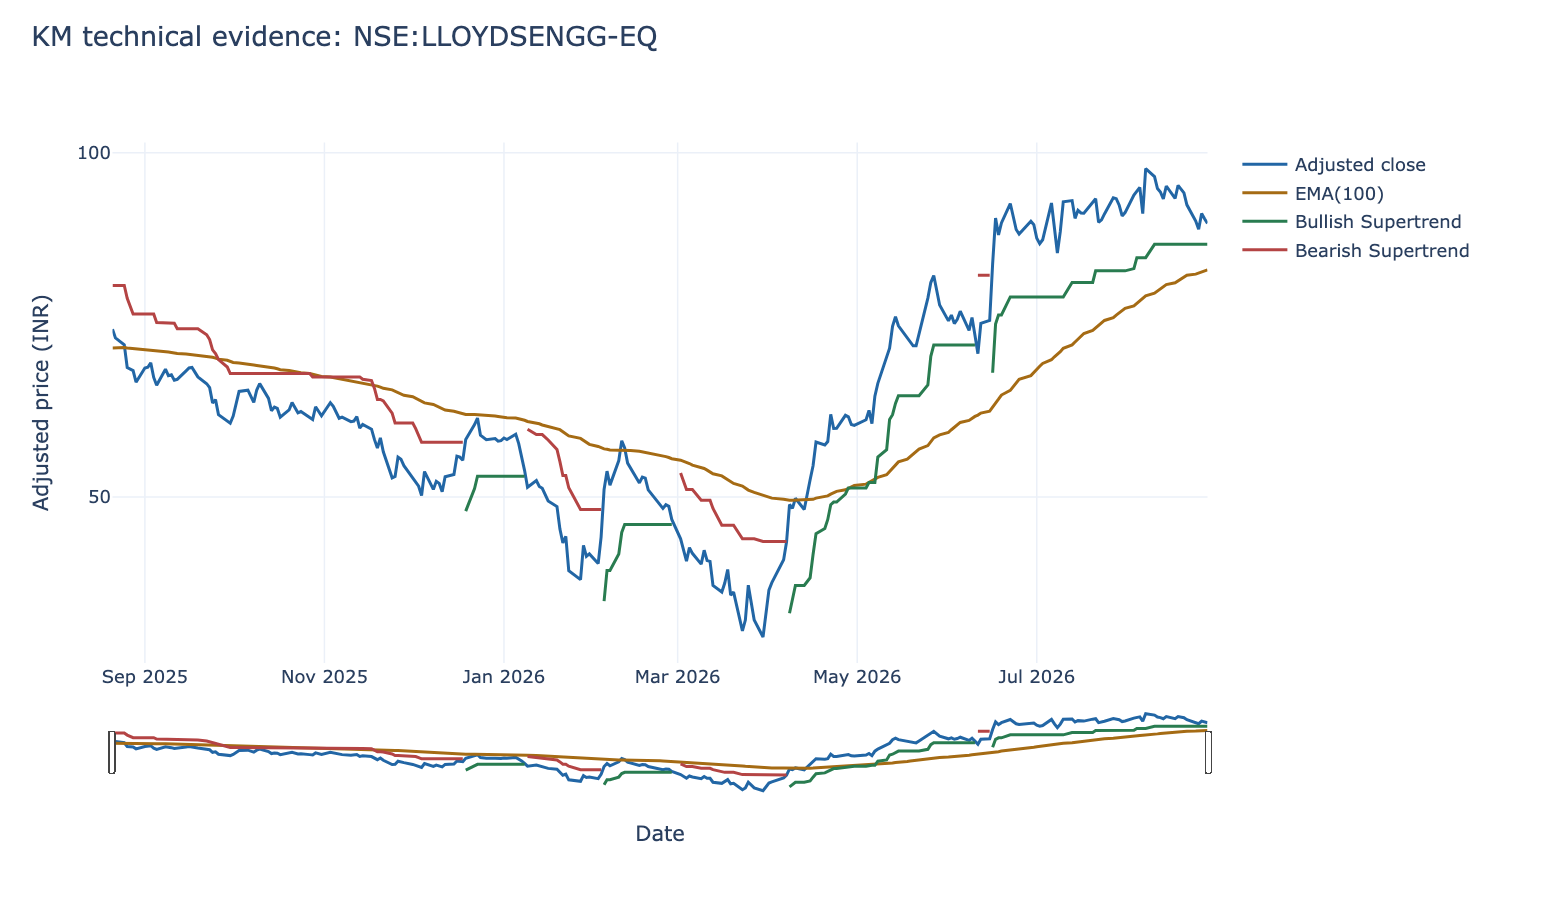

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,13.8%,13.0%,11.6%
1M,24,14.5%,13.8%,12.3%
1M,50,16.5%,15.7%,14.0%
3M,12,21.7%,20.7%,18.4%
3M,24,22.6%,21.7%,19.1%
3M,50,21.0%,20.2%,17.8%
6M,12,6.2%,5.7%,5.3%
6M,24,9.3%,8.8%,8.0%
6M,50,10.2%,9.7%,8.9%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,11.6%,0.372,-57.2%,6.1%
1M,24,12.3%,0.459,-54.0%,6.0%
1M,50,14.0%,0.608,-47.7%,5.6%
3M,12,18.4%,0.699,-33.4%,6.5%
3M,24,19.1%,0.806,-29.5%,5.6%
3M,50,17.8%,0.821,-29.1%,5.3%
6M,12,5.3%,-0.083,-29.8%,6.9%
6M,24,8.0%,0.128,-25.4%,4.6%
6M,50,8.9%,0.216,-23.1%,4.5%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,9.1%,92.9%,1648
1M,24,8.9%,89.5%,768
1M,50,7.6%,87.5%,817
3M,12,9.5%,93.2%,717
3M,24,8.5%,91.5%,739
3M,50,7.6%,90.7%,775
6M,12,9.4%,96.7%,830
6M,24,7.7%,94.6%,775
6M,50,6.8%,93.3%,809


### CAGR

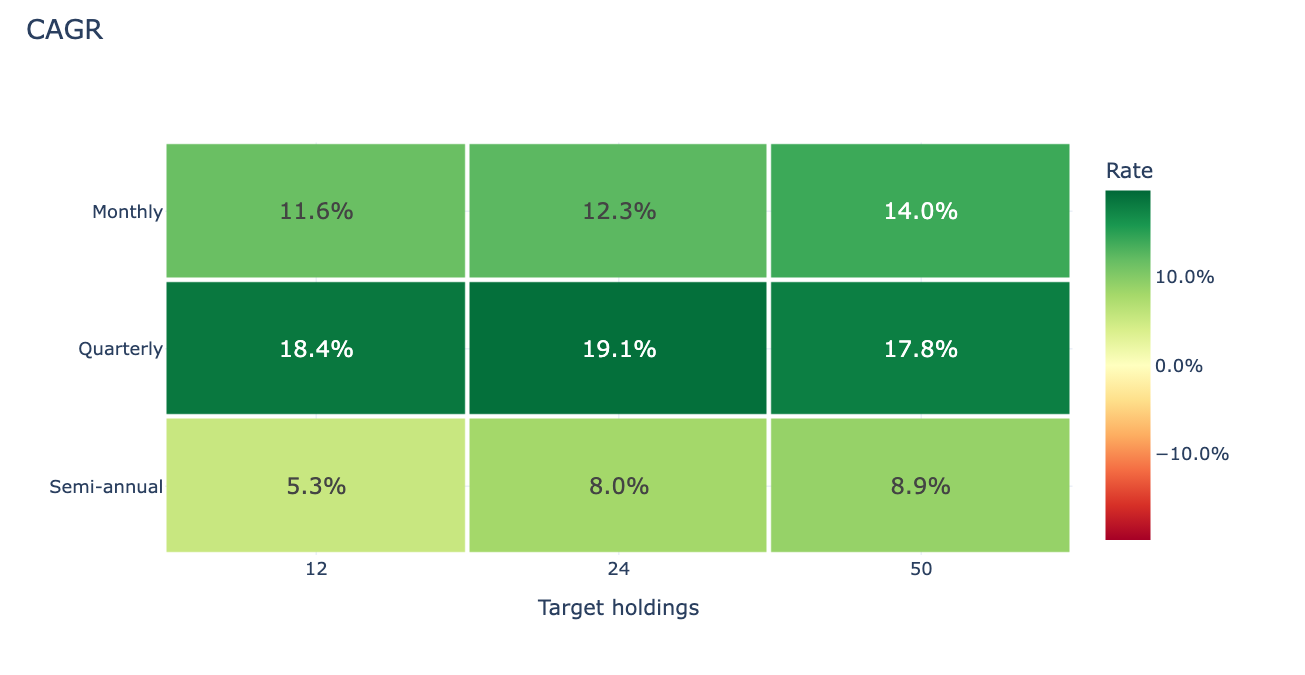

In [5]:
research.heatmap('cagr')

### Sharpe ratio

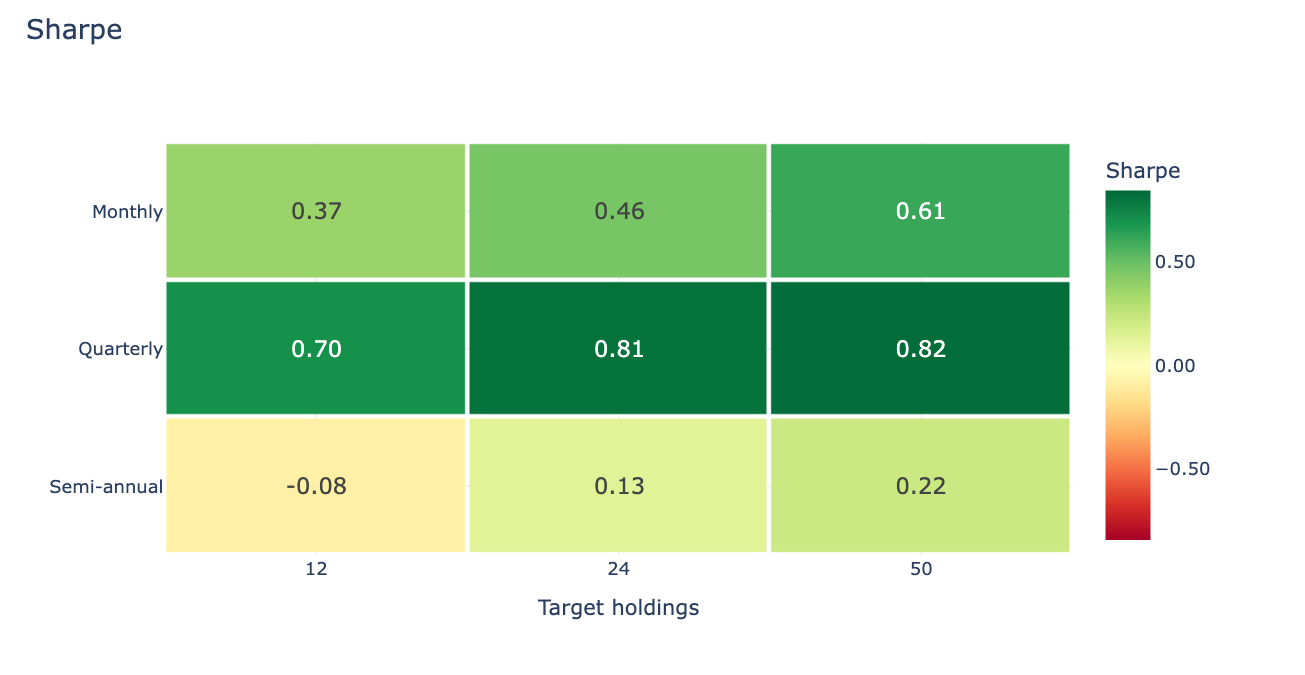

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

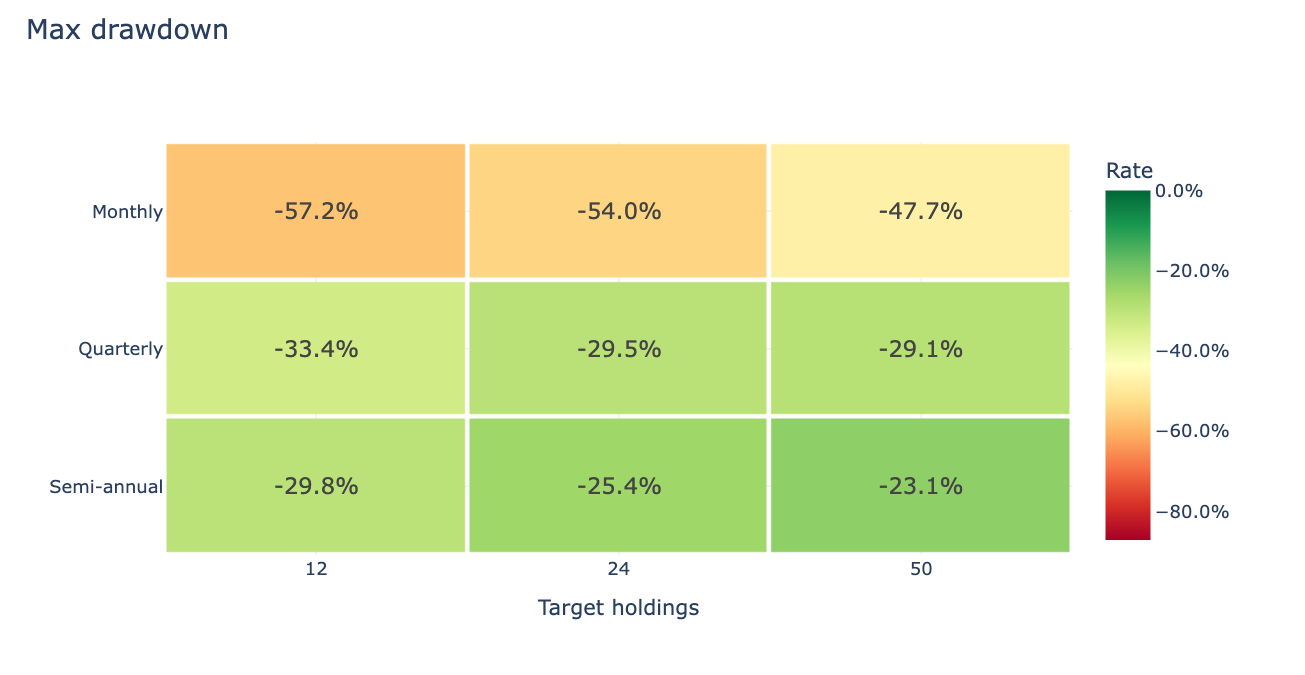

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

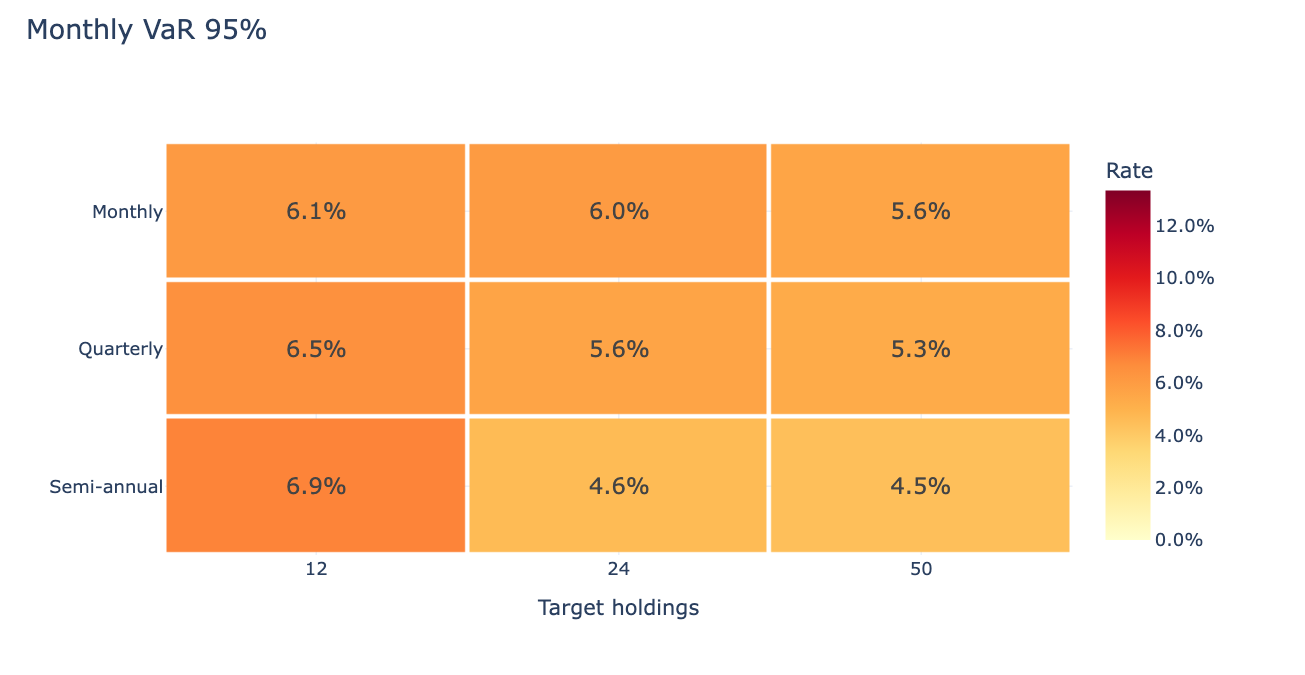

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

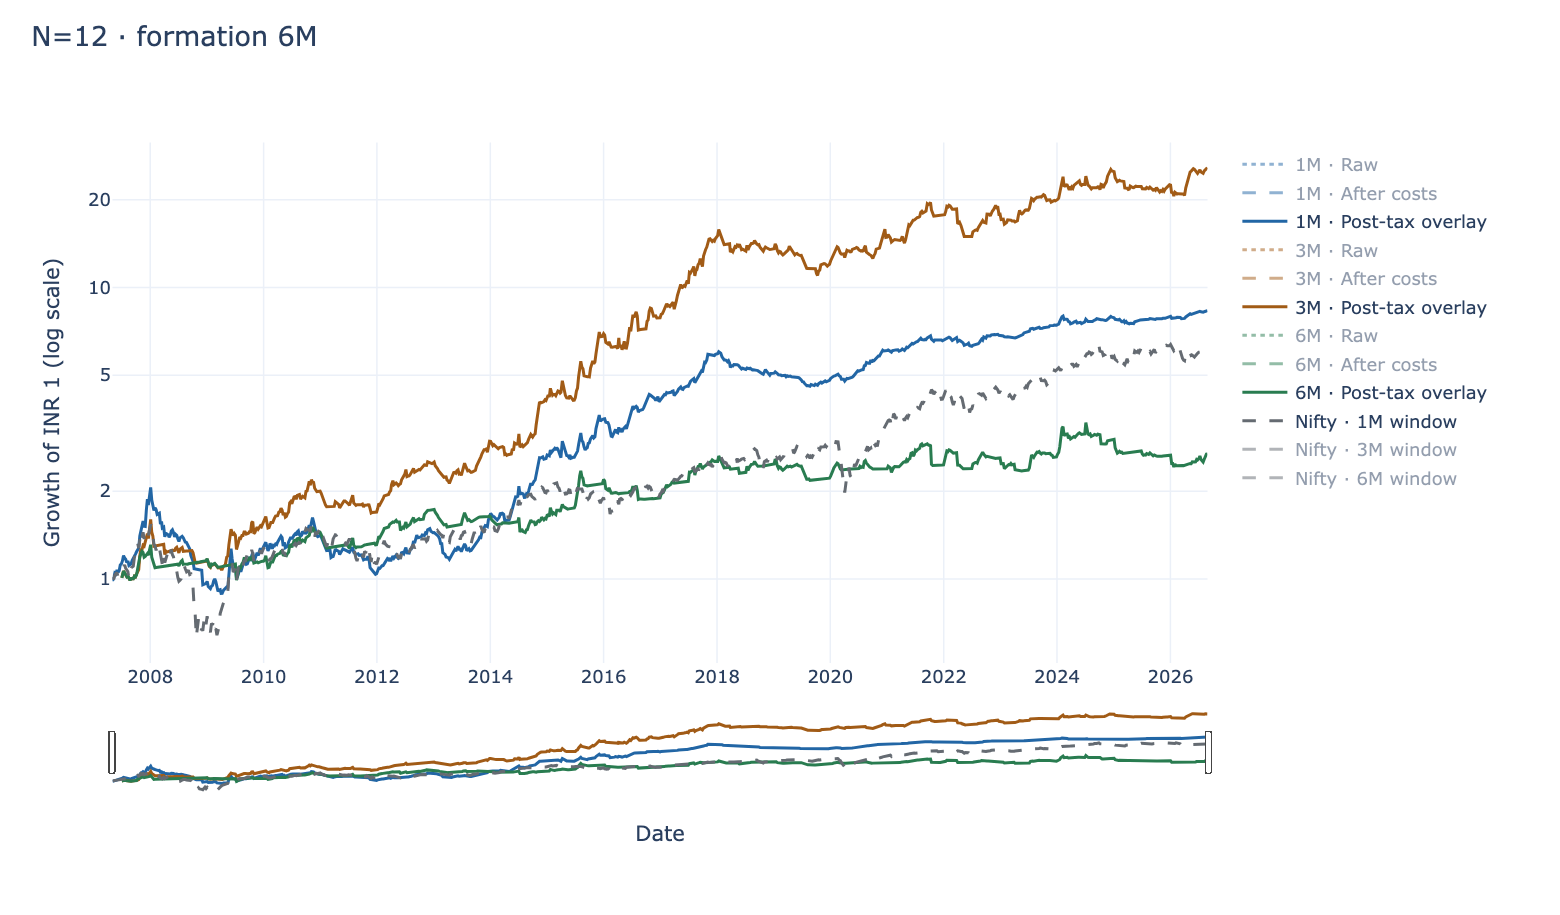

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,13.8%,0.525,-54.5%,5.8%
1M,After costs,13.0%,0.470,-55.8%,6.0%
1M,Post-tax overlay,11.6%,0.372,-57.2%,6.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,21.7%,0.877,-31.0%,6.3%
3M,After costs,20.7%,0.830,-31.9%,6.5%
3M,Post-tax overlay,18.4%,0.699,-33.4%,6.5%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,6.2%,-0.013,-29.5%,6.8%
6M,After costs,5.7%,-0.048,-29.8%,6.9%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,8.5%,91.3%,1579
1M,After costs,8.7%,92.1%,1597
3M,Raw,9.2%,92.2%,706
3M,After costs,9.3%,92.5%,708
6M,Raw,9.3%,96.4%,595
6M,After costs,9.4%,96.6%,608
1M,Post-tax overlay,9.1%,92.9%,1648
3M,Post-tax overlay,9.5%,93.2%,717
6M,Post-tax overlay,9.4%,96.7%,830
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

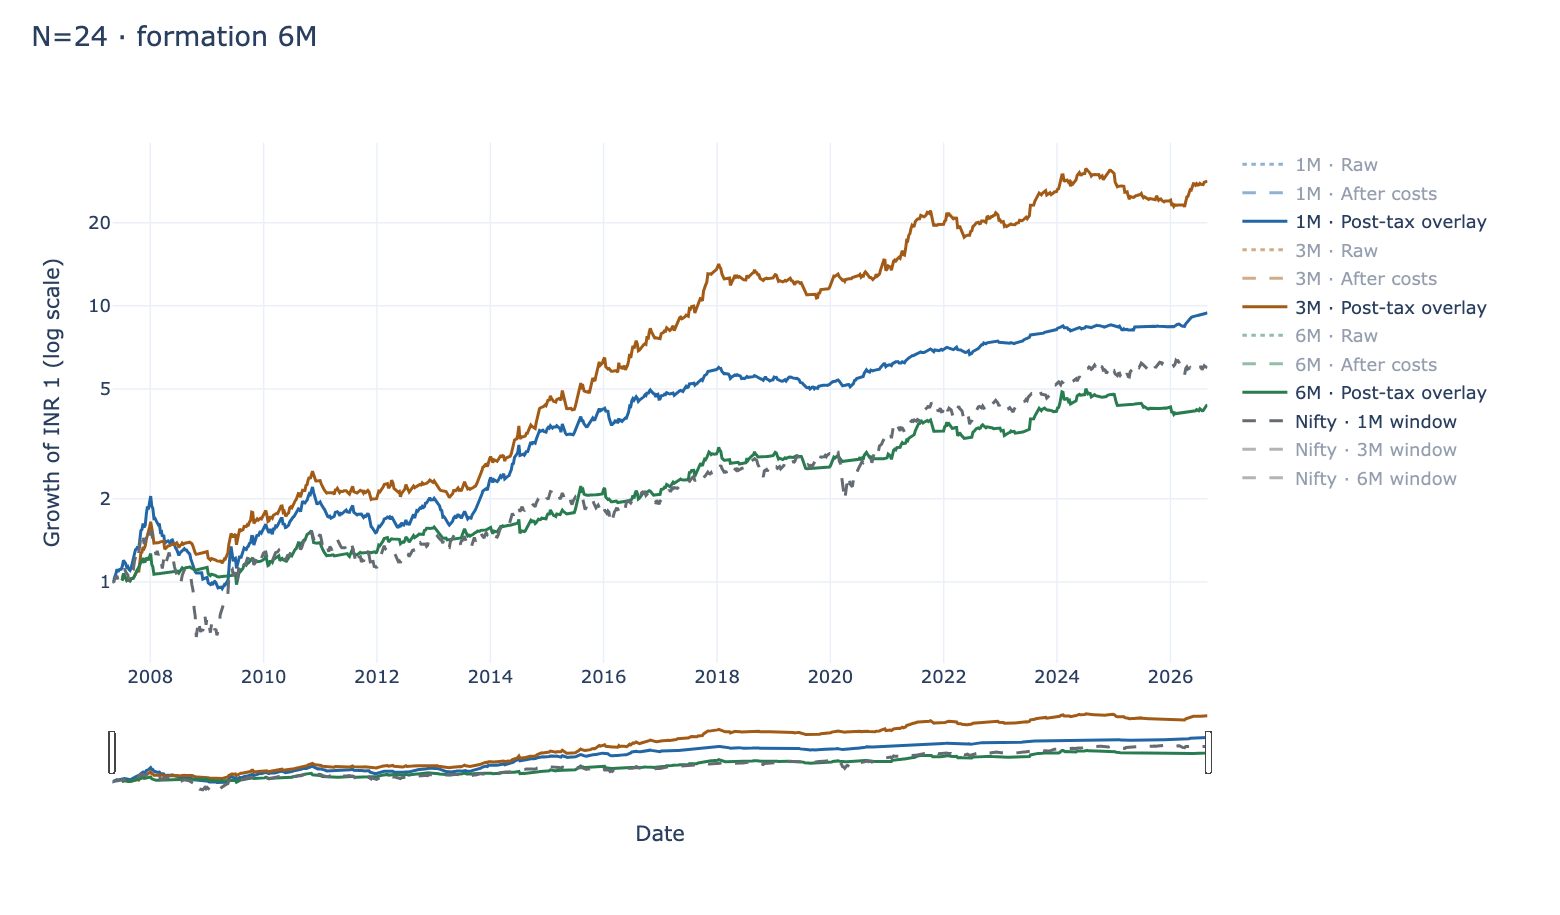

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,14.5%,0.636,-51.1%,5.9%
1M,After costs,13.8%,0.577,-52.4%,6.0%
1M,Post-tax overlay,12.3%,0.459,-54.0%,6.0%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,22.6%,1.026,-26.5%,5.0%
3M,After costs,21.7%,0.974,-27.5%,5.1%
3M,Post-tax overlay,19.1%,0.806,-29.5%,5.6%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,9.3%,0.239,-24.4%,4.5%
6M,After costs,8.8%,0.196,-25.1%,4.6%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,8.4%,87.2%,741
1M,After costs,8.6%,88.2%,753
3M,Raw,8.0%,90.3%,725
3M,After costs,8.2%,90.6%,733
6M,Raw,7.4%,93.9%,530
6M,After costs,7.6%,94.1%,758
1M,Post-tax overlay,8.9%,89.5%,768
3M,Post-tax overlay,8.5%,91.5%,739
6M,Post-tax overlay,7.7%,94.6%,775
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

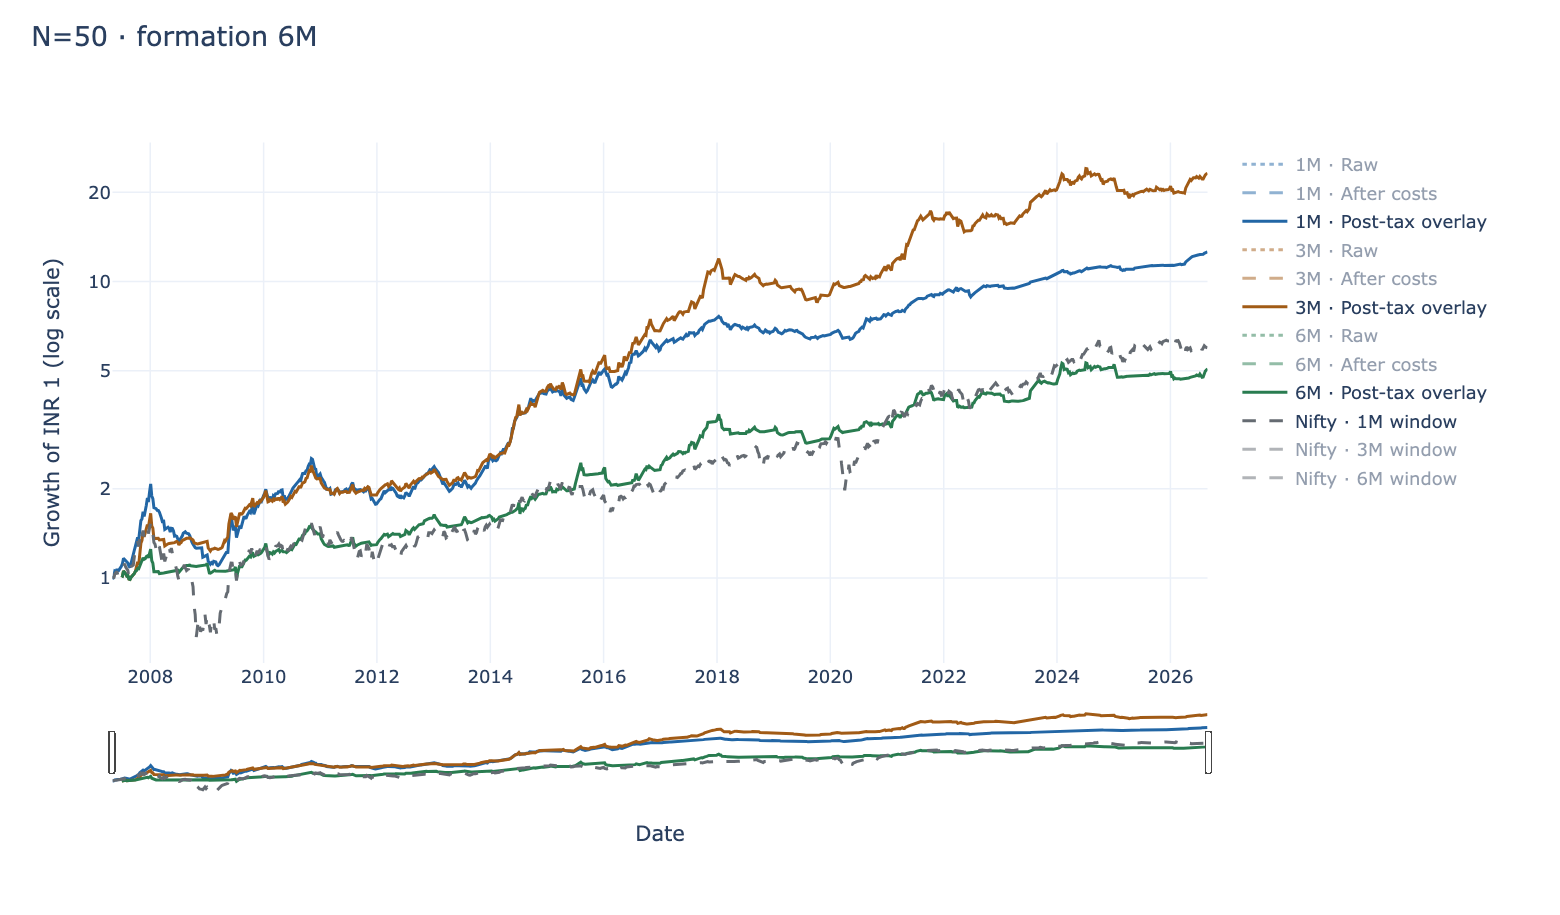

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,16.5%,0.820,-44.6%,5.1%
1M,After costs,15.7%,0.752,-45.7%,5.2%
1M,Post-tax overlay,14.0%,0.608,-47.7%,5.6%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,21.0%,1.054,-24.2%,5.1%
3M,After costs,20.2%,0.996,-25.3%,5.3%
3M,Post-tax overlay,17.8%,0.821,-29.1%,5.3%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.2%,0.345,-22.4%,4.2%
6M,After costs,9.7%,0.296,-23.1%,4.3%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,7.1%,84.7%,755
1M,After costs,7.2%,85.9%,769
3M,Raw,7.3%,88.7%,713
3M,After costs,7.4%,89.0%,730
6M,Raw,6.5%,91.8%,630
6M,After costs,6.7%,92.2%,765
1M,Post-tax overlay,7.6%,87.5%,817
3M,Post-tax overlay,7.6%,90.7%,775
6M,Post-tax overlay,6.8%,93.3%,809
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2010-11-11,2011-12-20,2013-12-19,768,1133,-33.2%
3M,2010-11-15,2011-11-21,2013-11-11,739,1091,-21.8%
6M,2018-01-15,2019-08-23,2021-03-09,775,1148,-17.1%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,19.42,42.4%,58.1%
1M,24,35.66,46.3%,58.0%
1M,50,69.38,46.4%,59.0%
3M,12,14.88,42.5%,29.2%
3M,24,28.31,43.2%,30.1%
3M,50,57.83,44.1%,34.5%
6M,12,13.85,60.3%,13.7%
6M,24,26.69,62.1%,12.0%
6M,50,54.10,63.1%,13.6%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,20.2%,"5,003,562.77",829
1M,24,19.4%,"5,643,243.50",1277
1M,50,18.5%,"7,376,925.82",1929
3M,12,43.9%,"15,980,434.79",575
3M,24,44.3%,"18,532,327.52",927
3M,50,40.9%,"14,622,121.00",1490
6M,12,45.2%,"1,637,318.15",349
6M,24,47.0%,"2,126,646.87",603
6M,50,46.8%,"2,425,111.08",990


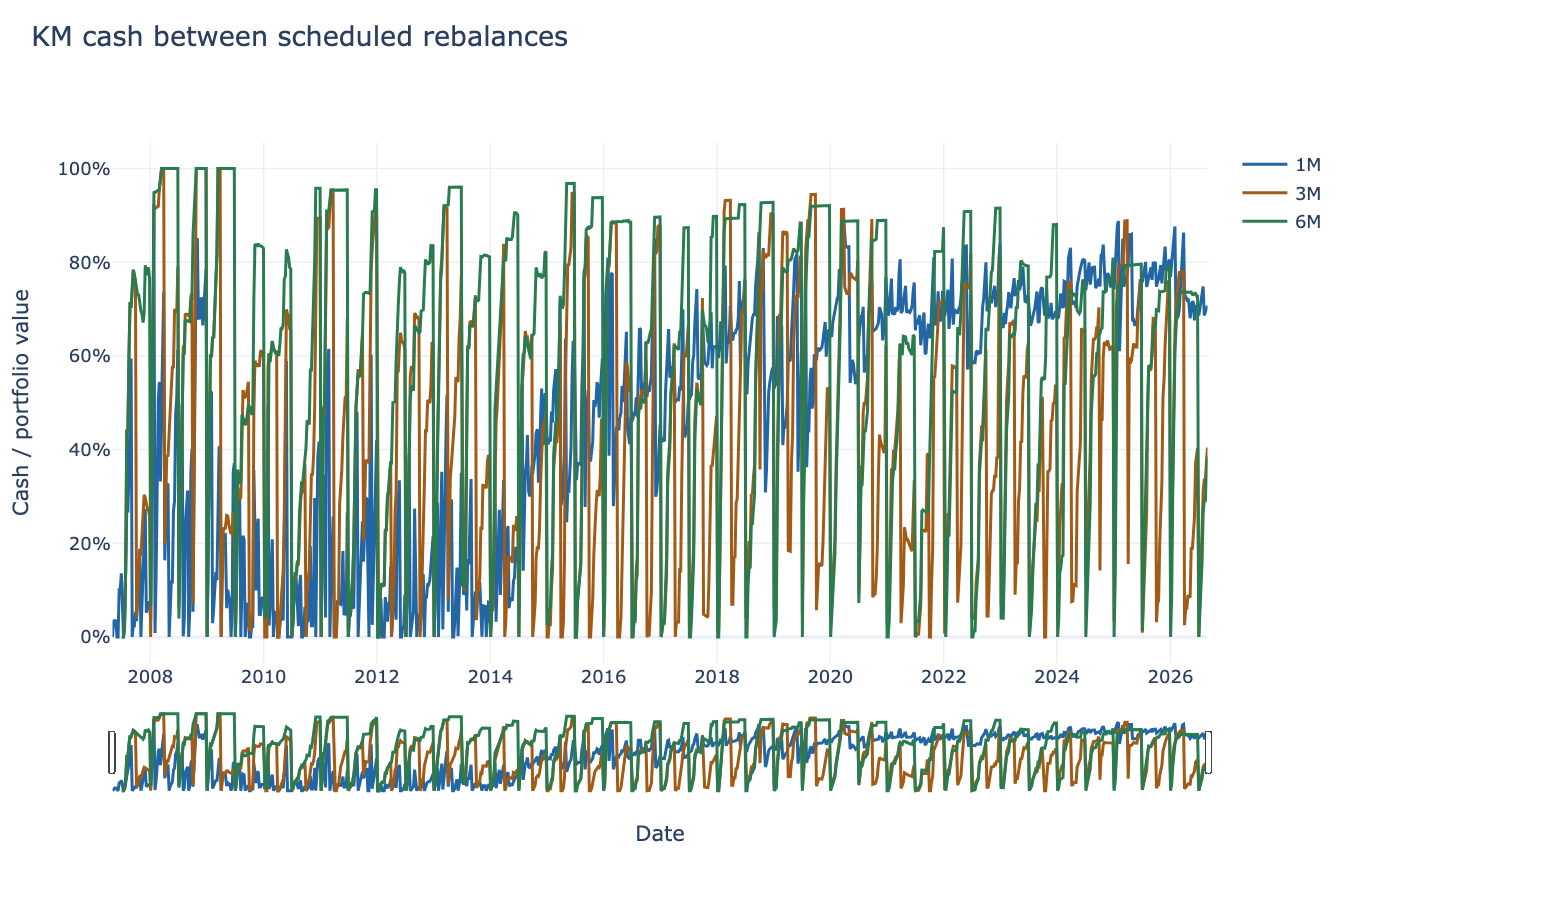

In [13]:
research.behavior()

## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

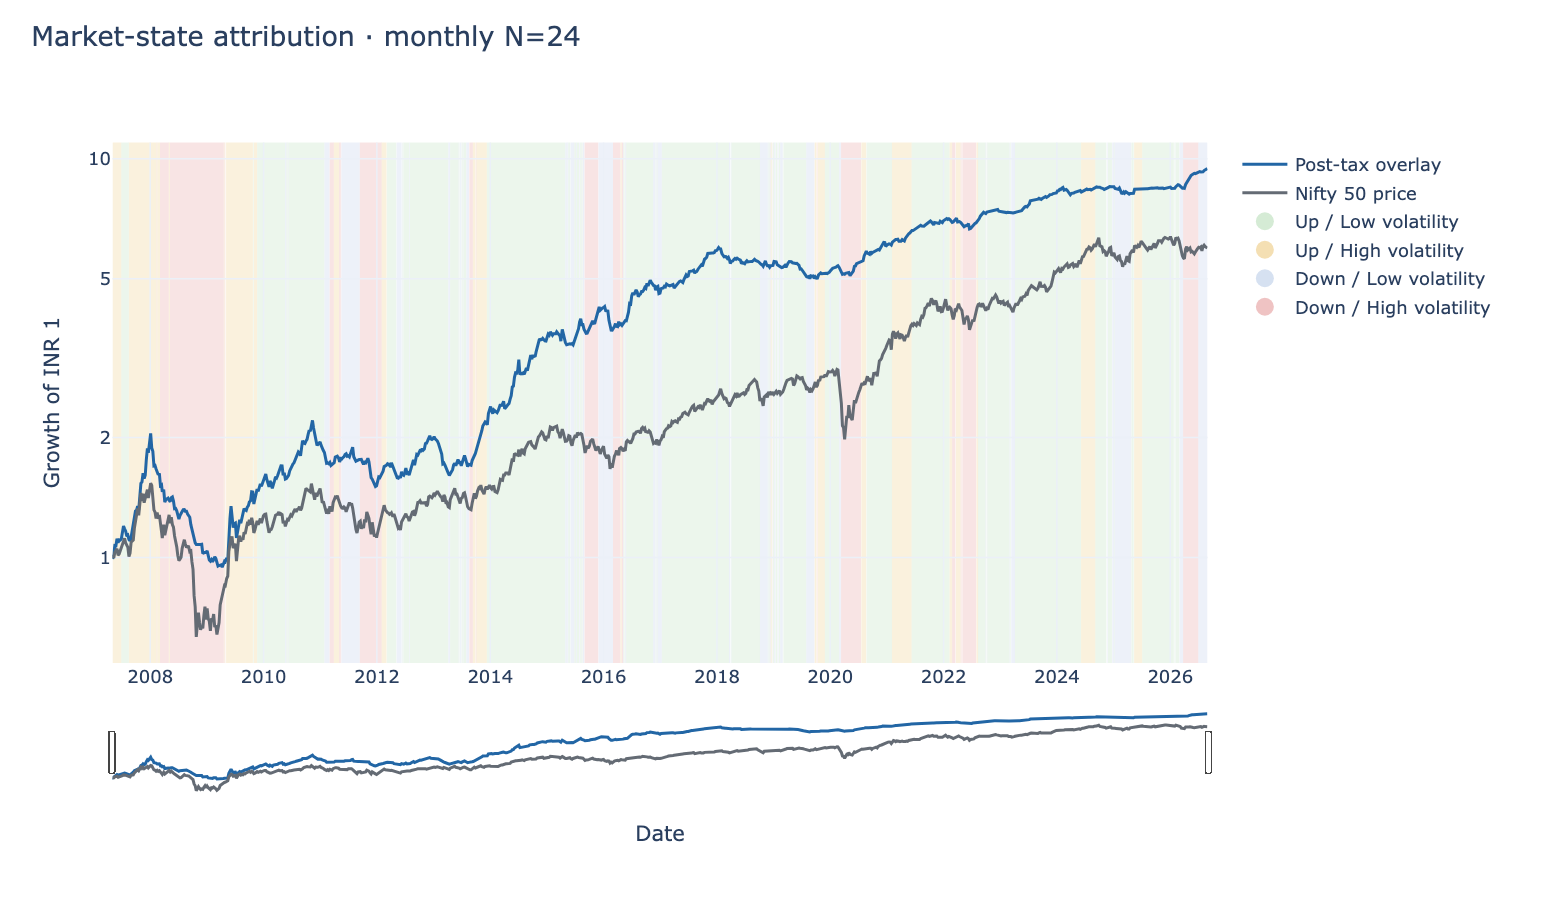

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.02%,0.70%,56.68%
Down / Low volatility,609,-0.02%,0.60%,54.35%
Up / High volatility,720,0.19%,1.15%,62.64%
Up / Low volatility,2694,0.05%,0.66%,58.43%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,4505
1M,24,2007-05-03,2026-08-03,232,8273
1M,50,2007-05-03,2026-08-03,232,16096
3M,12,2007-07-02,2026-07-01,77,1146
3M,24,2007-07-02,2026-07-01,77,2180
3M,50,2007-07-02,2026-07-01,77,4453
6M,12,2007-07-02,2026-07-01,39,540
6M,24,2007-07-02,2026-07-01,39,1041
6M,50,2007-07-02,2026-07-01,39,2110


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 6M — Winner Drift](03_raw_momentum_6m_winner_drift.ipynb). The comparison holds formation, maintenance, frequency and N fixed.